In [5]:
import pandas as pd
import re

In [21]:
import sys
sys.path.append('..')

In [22]:
from src.slices_pipeline.encoder import *
from src.slices_pipeline.loader import *

In [41]:
from pymatgen.core.composition import Composition

def update_result(df):
    def count_atoms(formula):
        try:
            comp = Composition(formula)
            return comp.num_atoms
        except Exception:
            return None  # или 0, если так удобнее

    df['atom_count'] = df['pretty_formula'].apply(count_atoms)
    return df

def read_results(file, split_file):
    rows = []
    pattern = r'^(?P<status>E|x)?\s*(?P<idx>\d+):\s*(?P<material>[a-zA-Z]+-\d+)\s*---\s*(?P<time>[\d\.eE+-]+)'

    for line in open(file).read().strip().split('\n'):
        m = re.match(pattern, line)
        if m:
            rows.append({
                'status': m.group('status') or '',
                'idx': int(m.group('idx')),
                'material_id': m.group('material'),
                'time': float(m.group('time')),
            })

    df = pd.DataFrame(rows)

    split = read_split_df(split_file)

    result = pd.merge(df, split, on='material_id', how='inner')

    return update_result(result)

In [42]:
tests = read_results("results.txt", "test")
tests

,status,idx,material_id,time,Unnamed: 0,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,atom_count
0,E,0,mp-10009,0.179174,6000,-0.575092,0.8980,GaTe,0.000000,"['Ga', 'Te']",# generated using pymatgen\ndata_GaTe\n_symmet...,194,2.0
1,E,1,mp-1218989,0.137652,37702,-0.942488,0.0000,SmThCN,0.044109,"['C', 'N', 'Sm', 'Th']",# generated using pymatgen\ndata_SmThCN\n_symm...,160,4.0
2,x,2,mp-1225695,1.188268,42245,0.064863,0.0000,CuNi,0.064863,"['Cu', 'Ni']",# generated using pymatgen\ndata_CuNi\n_symmet...,65,2.0
3,,3,mp-1220884,1.707755,780,-1.456116,0.0000,NaTiVS4,0.000000,"['Na', 'S', 'Ti', 'V']",# generated using pymatgen\ndata_NaTiVS4\n_sym...,8,7.0
4,,4,mp-1224266,2.922140,35749,0.024139,0.0000,Ho3TmMn8,0.036496,"['Ho', 'Mn', 'Tm']",# generated using pymatgen\ndata_Ho3TmMn8\n_sy...,8,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9041,,9041,mp-21084,3.431612,7763,-1.777752,1.0134,In6Ga2PtO8,0.000000,"['Ga', 'In', 'O', 'Pt']",# generated using pymatgen\ndata_In6Ga2PtO8\n_...,225,17.0
9042,,9042,mp-571486,4.601307,15377,-0.359373,0.0000,CuSe,0.000000,"['Cu', 'Se']",# generated using pymatgen\ndata_CuSe\n_symmet...,63,2.0
9043,,9043,mp-14410,6.725072,17730,-1.205080,0.4594,Tl6TeO12,0.000000,"['O', 'Te', 'Tl']",# generated using pymatgen\ndata_Tl6TeO12\n_sy...,148,19.0
9044,,9044,mp-1079192,1.939557,28030,-2.814520,0.0000,Sr2GdRuO6,0.014361,"['Gd', 'O', 'Ru', 'Sr']",# generated using pymatgen\ndata_Sr2GdRuO6\n_s...,87,10.0


In [19]:
tests.status.value_counts(), tests.groupby('status').time.mean()

(status
      7743
 E     807
 x     496
 Name: count, dtype: int64,
 status
      2.563727
 E    0.870310
 x    6.323608
 Name: time, dtype: float64)

<Axes: xlabel='atom_count'>

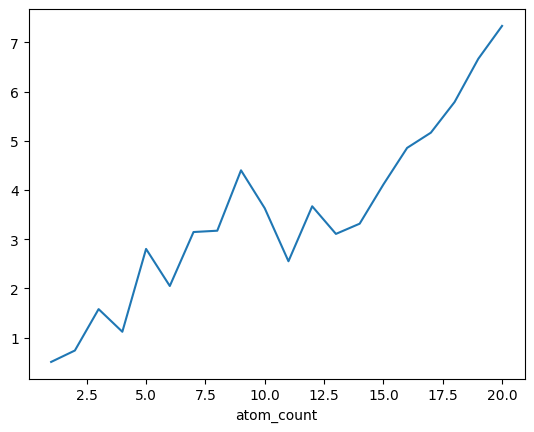

In [52]:
tests[tests.status == ''].groupby('atom_count').time.mean().plot()

atom_count
1.0       69
2.0      348
3.0     1112
4.0     2012
5.0     1052
6.0      649
7.0      619
8.0      497
9.0      540
10.0     921
11.0     116
12.0     175
13.0     193
14.0     146
15.0     115
16.0     112
17.0      82
18.0      69
19.0      78
20.0     141
Name: count, dtype: int64


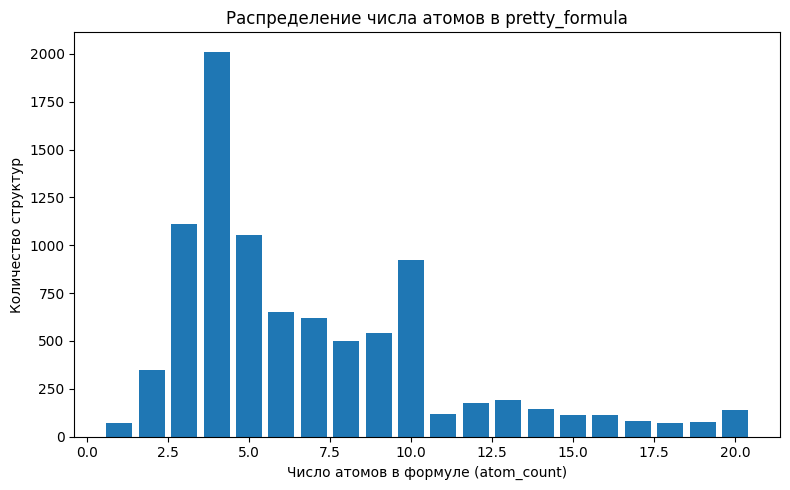

In [58]:
import matplotlib.pyplot as plt

# Если ты уже сделал столбец atom_count, как выше:
counts = tests['atom_count'].value_counts().sort_index()
print(counts)  # Количество структур для каждого числа атомов

# Нарисовать гистограмму:
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.xlabel('Число атомов в формуле (atom_count)')
plt.ylabel('Количество структур')
plt.title('Распределение числа атомов в pretty_formula')
plt.tight_layout()
plt.show()


status
     7743
E     807
x     496
Name: count, dtype: int64
            time  formation_energy_per_atom  band_gap
status                                               
        2.563727                  -1.188054  0.708152
E       0.870310                  -1.247150  1.198603
x       6.323608                  -1.504702  1.308599
[('O', 2239), ('Li', 788), ('Cu', 694), ('F', 656), ('S', 642), ('Ni', 613), ('Mn', 524), ('Al', 521), ('Mg', 499), ('Fe', 498)]


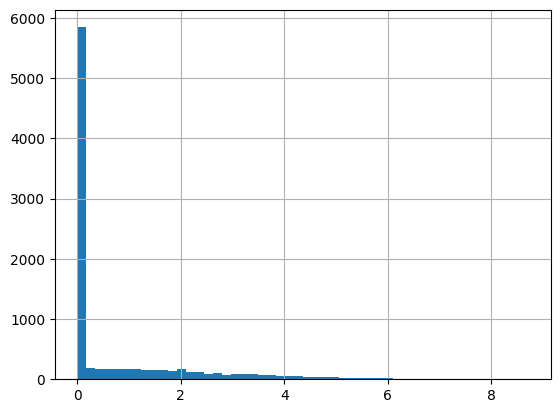

In [38]:
# Количество по статусу
print(tests['status'].value_counts())

# Средние значения для разных статусов
print(tests.groupby('status')[['time', 'formation_energy_per_atom', 'band_gap']].mean())

# Гистограмма band_gap
tests['band_gap'].hist(bins=50)

# Самые часто встречающиеся элементы
import ast
from collections import Counter
counter = Counter()
for els in tests['elements']:
    counter.update(ast.literal_eval(els))
print(counter.most_common(10))
